In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import subprocess, sys

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

In [8]:
import zipfile, os


ZIP_PATH   = "/content/drive/MyDrive/cig_ps.zip"
EXTRACT_TO = "/content"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_TO)

print("Extracted!")
print(os.listdir("/content/cig_ps"))

Extracted!
['train_images', 'train-labels.csv', 'test_images']


In [9]:
BASE_DIR      = "/content/cig_ps"
TRAIN_IMG_DIR = "/content/cig_ps/train_images"
TEST_IMG_DIR  = "/content/cig_ps/test_images"
TRAIN_CSV     = "/content/cig_ps/train-labels.csv"

In [10]:
IMG_H      = 32
IMG_W      = 128
BATCH_SIZE = 128
EPOCHS     = 15
VAL_SPLIT  = 0.1
LR         = 1e-3

RNN_UNITS  = 128

In [11]:
import pandas as pd

In [12]:

df = pd.read_csv(TRAIN_CSV)
print(f"\nTotal training samples : {len(df)}")
print(df.head())


Total training samples : 20000
   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E
3           3  train-3.png  SM424H
4           4  train-4.png  6YVTQR


In [13]:

all_chars   = sorted(set("".join(df["text"].tolist())))

BLANK       = len(all_chars)           # Keras CTC uses LAST index as blank
VOCAB       = all_chars + ["<BLANK>"]
char2idx    = {c: i for i, c in enumerate(all_chars)}
idx2char    = {i: c for c, i in char2idx.items()}
NUM_CLASSES = len(VOCAB)

MAX_LABEL_LEN = df["text"].str.len().max()

print(f"\nVocab size (with blank) : {NUM_CLASSES}")
print(f"Characters              : {all_chars}")
print(f"Max label length        : {MAX_LABEL_LEN}")


Vocab size (with blank) : 39
Characters              : ['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']
Max label length        : 9


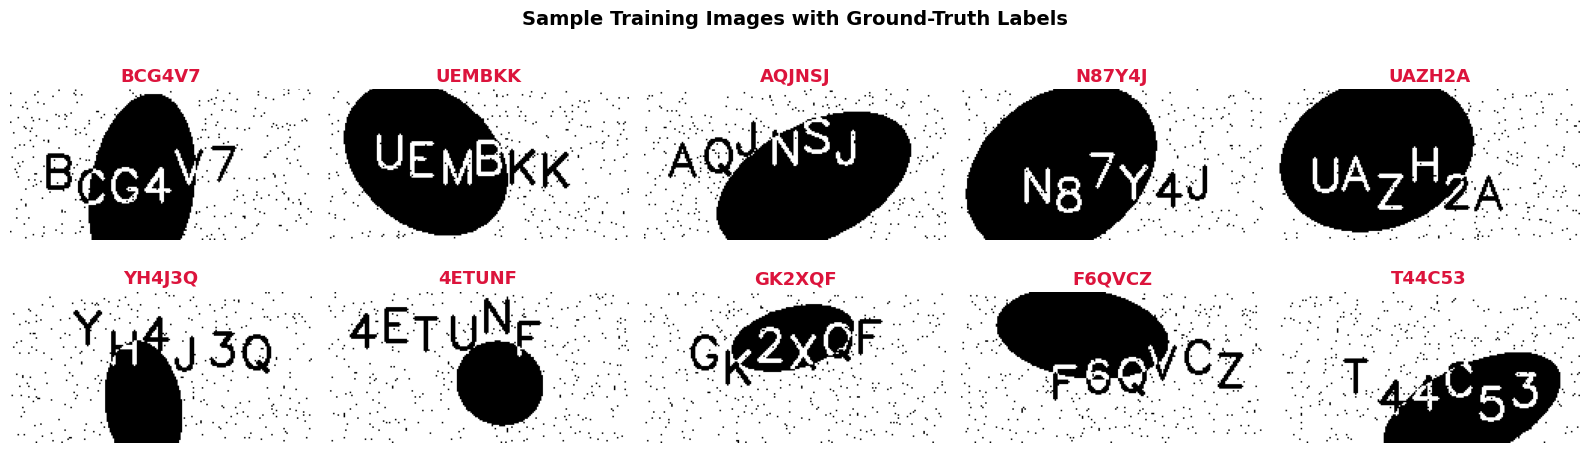

In [14]:

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(16, 5))
sample_df = df.sample(10, random_state=7).reset_index(drop=True)

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    img = Image.open(os.path.join(TRAIN_IMG_DIR, row["image"])).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(row["text"], fontsize=13, fontweight="bold", color="crimson")
    ax.axis("off")

plt.suptitle("Sample Training Images with Ground-Truth Labels",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "sample_images.png"), dpi=120, bbox_inches="tight")
plt.show()


In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from sklearn.model_selection import train_test_split

# Seed TensorFlow
tf.random.set_seed(42)

print(f"\nTensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs found : {len(gpus)}")


TensorFlow : 2.20.0
Keras      : 3.13.2
GPUs found : 1


In [16]:
import numpy as np
class CaptchaGenerator(keras.utils.Sequence):


    def __init__(self, df, img_dir, char2idx, img_h, img_w,
                 max_label_len, batch_size, augment=False, shuffle=True):
        self.df           = df.reset_index(drop=True)
        self.img_dir      = img_dir
        self.char2idx     = char2idx
        self.img_h        = img_h
        self.img_w        = img_w
        self.max_label_len = max_label_len
        self.batch_size   = batch_size
        self.augment      = augment
        self.shuffle      = shuffle
        self.indices      = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _load_image(self, fname):
        img = Image.open(os.path.join(self.img_dir, fname)).convert("L")
        img = img.resize((self.img_w, self.img_h), Image.BILINEAR)
        img = np.array(img, dtype=np.float32) / 255.0

        if self.augment:

            img = img * np.random.uniform(0.75, 1.25)
            img = np.clip(img, 0.0, 1.0)

        img = img[..., np.newaxis]
        return img

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch     = self.df.iloc[batch_idx]

        images       = np.zeros((len(batch), self.img_h, self.img_w, 1), dtype=np.float32)
        labels       = np.full((len(batch), self.max_label_len), -1, dtype=np.int32)
        input_lens   = np.zeros((len(batch), 1), dtype=np.int32)
        label_lens   = np.zeros((len(batch), 1), dtype=np.int32)

        for i, (_, row) in enumerate(batch.iterrows()):
            images[i]     = self._load_image(row["image"])
            encoded       = [self.char2idx[c] for c in row["text"]]
            labels[i, :len(encoded)] = encoded
            label_lens[i] = len(encoded)


        input_lens[:] = self.img_w // 4

        inputs = {
            "image":        images,
            "label":        labels,
            "input_length": input_lens,
            "label_length": label_lens,
        }

        targets = np.zeros(len(batch), dtype=np.float32)

        return inputs, targets


In [17]:
train_df, val_df = train_test_split(df, test_size=VAL_SPLIT, random_state=42)
print(f"\nTrain : {len(train_df)}  |  Val : {len(val_df)}")

train_gen = CaptchaGenerator(train_df, TRAIN_IMG_DIR, char2idx,
                              IMG_H, IMG_W, MAX_LABEL_LEN, BATCH_SIZE,
                              augment=True,  shuffle=True)
val_gen   = CaptchaGenerator(val_df,   TRAIN_IMG_DIR, char2idx,
                              IMG_H, IMG_W, MAX_LABEL_LEN, BATCH_SIZE,
                              augment=False, shuffle=False)



Train : 18000  |  Val : 2000


In [18]:
def build_crnn_model(img_h, img_w, num_classes, rnn_units):


    # ── Inputs ────────────────────────────────────────────────────────────────
    image_input   = keras.Input(shape=(img_h, img_w, 1),  name="image")
    label_input   = keras.Input(shape=(None,),             name="label",        dtype="int32")
    input_len_inp = keras.Input(shape=(1,),                name="input_length",  dtype="int32")
    label_len_inp = keras.Input(shape=(1,),                name="label_length",  dtype="int32")

    # ── CNN Backbone ──────────────────────────────────────────────────────────
    x = layers.Conv2D(64, 3, padding="same", name="conv1")(image_input)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.ReLU(name="relu1")(x)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x)

    x = layers.Conv2D(128, 3, padding="same", name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.ReLU(name="relu2")(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)

    x = layers.Conv2D(256, 3, padding="same", name="conv3a")(x)
    x = layers.BatchNormalization(name="bn3a")(x)
    x = layers.ReLU(name="relu3a")(x)
    x = layers.Conv2D(256, 3, padding="same", name="conv3b")(x)
    x = layers.BatchNormalization(name="bn3b")(x)
    x = layers.ReLU(name="relu3b")(x)
    x = layers.MaxPooling2D((2, 1), name="pool3")(x)

    x = layers.Conv2D(512, 3, padding="same", name="conv4a")(x)
    x = layers.BatchNormalization(name="bn4a")(x)
    x = layers.ReLU(name="relu4a")(x)
    x = layers.Conv2D(512, 3, padding="same", name="conv4b")(x)
    x = layers.BatchNormalization(name="bn4b")(x)
    x = layers.ReLU(name="relu4b")(x)
    x = layers.MaxPooling2D((2, 1), name="pool4")(x)

    x = layers.Conv2D(512, (4, 3), padding="same", name="conv5")(x)
    x = layers.BatchNormalization(name="bn5")(x)
    x = layers.ReLU(name="relu5")(x)
    x = layers.Dropout(0.25, name="drop5")(x)

    shape = x.shape
    x = layers.Reshape(
        target_shape=(shape[2], shape[1] * shape[3]),
        name="reshape"
    )(x)

    x = layers.Dense(256, activation="relu", name="dense_proj")(x)

    # ── Bidirectional LSTM ────────────────────────────────────────────────────
    x = layers.Bidirectional(
        layers.LSTM(rnn_units, return_sequences=True, dropout=0.3),
        name="bilstm1"
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(rnn_units, return_sequences=True, dropout=0.3),
        name="bilstm2"
    )(x)

    # ── Output: per time-step class probabilities ─────────────────────────────
    output = layers.Dense(num_classes, activation="softmax", name="softmax")(x)


    # ── CTC Loss Layer ────────────────────────────────────────────────────────
    def ctc_loss_fn(args):
        y_pred, labels, input_length, label_length = args
        return K.ctc_batch_cost(labels, y_pred, input_length, label_length)

    ctc_loss = layers.Lambda(ctc_loss_fn, name="ctc_loss")(
        [output, label_input, input_len_inp, label_len_inp]
    )

    # ── Training model (optimises CTC loss) ───────────────────────────────────
    training_model = Model(
        inputs  = [image_input, label_input, input_len_inp, label_len_inp],
        outputs = ctc_loss,
        name    = "crnn_training"
    )
    training_model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=LR),
        loss      = lambda y_true, y_pred: y_pred   # loss already computed inside
    )

    # ── Prediction model (image → softmax probs) ──────────────────────────────
    prediction_model = Model(
        inputs  = image_input,
        outputs = output,
        name    = "crnn_prediction"
    )

    return training_model, prediction_model


training_model, prediction_model = build_crnn_model(IMG_H, IMG_W, NUM_CLASSES, RNN_UNITS)

training_model.summary()
print(f"\nPrediction model output : {prediction_model.output_shape}")

Model: "crnn_training"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 128,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 32, 128,   │        640 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 32, 128,   │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (ReLU)        │ (None, 32, 128,   │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 16, 64,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 16, 64,    │     73,856 │ pool1[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 16, 64,    │        512 │ conv2[0][0]       │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu2 (ReLU)        │ (None, 16, 64,    │          0 │ bn2[0][0]         │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 8, 32,     │          0 │ relu2[0][0]       │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3a (Conv2D)     │ (None, 8, 32,     │    295,168 │ pool2[0][0]       │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3a                │ (None, 8, 32,     │      1,024 │ conv3a[0][0]      │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu3a (ReLU)       │ (None, 8, 32,     │          0 │ bn3a[0][0]        │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3b (Conv2D)     │ (None, 8, 32,     │    590,080 │ relu3a[0][0]      │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3b                │ (None, 8, 32,     │      1,024 │ conv3b[0][0]      │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu3b (ReLU)       │ (None, 8, 32,     │          0 │ bn3b[0][0]        │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 4, 32,     │          0 │ relu3b[0][0]      │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4a (Conv2D)     │ (None, 4, 32,     │  1,180,160 │ pool3[0][0]     

 Total params: 8,715,815 (33.25 MB)

 Trainable params: 8,711,335 (33.23 MB)

 Non-trainable params: 4,480 (17.50 KB)


Prediction model output : (None, 32, 39)


In [19]:
def greedy_decode(y_pred, idx2char, blank_idx):

    results = []
    pred_ids = np.argmax(y_pred, axis=-1)
    for seq in pred_ids:
        chars, prev = [], -1
        for tok in seq:
            if tok != prev and tok != blank_idx:
                chars.append(idx2char.get(tok, ""))
            prev = tok
        results.append("".join(chars))
    return results


def levenshtein(s1, s2):
    m, n = len(s1), len(s2)
    dp = list(range(m + 1))
    for j in range(1, n + 1):
        prev, dp[0] = dp[0], j
        for i in range(1, m + 1):
            temp  = dp[i]
            dp[i] = prev if s1[i-1] == s2[j-1] else 1 + min(dp[i], dp[i-1], prev)
            prev  = temp
    return dp[m]


def cer(pred, target):
    if len(target) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return levenshtein(pred, target) / len(target)


def evaluate_cer(prediction_model, generator, idx2char, blank_idx, n_batches=20):

    all_cer = []
    for i in range(min(n_batches, len(generator))):
        inputs, _ = generator[i]
        images     = inputs["image"]
        labels     = inputs["label"]
        label_lens = inputs["label_length"].flatten()

        y_pred = prediction_model.predict(images, verbose=0)
        preds  = greedy_decode(y_pred, idx2char, blank_idx)

        for pred, label, llen in zip(preds, labels, label_lens):
            gt = "".join(idx2char.get(int(c), "") for c in label[:llen])
            all_cer.append(cer(pred, gt))

    return float(np.mean(all_cer))

print("Decoder & CER ready ")


# ── Section 10: Callbacks ─────────────────────────────────────────────────────
CKPT_PATH = os.path.join(BASE_DIR, "best_crnn_keras.h5")

class CERCallback(keras.callbacks.Callback):


    def __init__(self, val_gen, prediction_model, idx2char, blank_idx):
        super().__init__()
        self.val_gen          = val_gen
        self.prediction_model = prediction_model
        self.idx2char         = idx2char
        self.blank_idx        = blank_idx
        self.cer_history      = []
        self.best_cer         = float("inf")

    def on_epoch_end(self, epoch, logs=None):
        val_cer = evaluate_cer(
            self.prediction_model, self.val_gen,
            self.idx2char, self.blank_idx, n_batches=30
        )
        self.cer_history.append(val_cer)
        logs["val_cer"] = val_cer

        marker = ""
        if val_cer < self.best_cer:
            self.best_cer = val_cer
            marker = "  ✓ best"

        print(f"  Val CER: {val_cer:.4f}{marker}")


cer_callback = CERCallback(val_gen, prediction_model, idx2char, BLANK)

callbacks = [
    cer_callback,
    keras.callbacks.ModelCheckpoint(
        filepath        = CKPT_PATH,
        monitor         = "val_loss",
        save_best_only  = True,
        verbose         = 1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 4,
        verbose  = 1,
        min_lr   = 1e-6
    ),
    keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 8,
        restore_best_weights = True,
        verbose              = 1
    ),
]



Decoder & CER ready 


In [20]:
print(f"\nStarting training for up to {EPOCHS} epochs...\n")

history = training_model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = EPOCHS,
    callbacks       = callbacks,
    verbose         = 1,
)

print(f"\nBest Val CER : {cer_callback.best_cer:.4f}")


Starting training for up to 15 epochs...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - loss: 27.6802  Val CER: 1.0000  ✓ best

Epoch 1: val_loss improved from None to 22.36284, saving model to /content/cig_ps/best_crnn_keras.h5



Epoch 1: finished saving model to /content/cig_ps/best_crnn_keras.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 79s 434ms/step - loss: 23.5635 - val_loss: 22.3628 - val_cer: 1.0000 - learning_rate: 0.0010
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - loss: 22.3570  Val CER: 1.0000

Epoch 2: val_loss did not improve from 22.36284
141/141 ━━━━━━━━━━━━━━━━━━━━ 53s 374ms/step - loss: 22.3425 - val_loss: 22.4036 - val_cer: 1.0000 - learning_rate: 0.0010
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - loss: 22.2676  Val CER: 1.0000

Epoch 3: val_loss improved from 22.36284 to 22.23722, saving model to /content/cig_ps/best_crnn_keras.h5



Epoch 3: finished saving model to /content/cig_ps/best_crnn_keras.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 382ms/step - loss: 22.1972 - val_loss: 22.2372 - val_cer: 1.0000 - learning_rate: 0.0010
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - loss: 21.9214  Val CER: 0.9684  ✓ best

Epoch 4: val_loss did not improve from 22.23722
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 383ms/step - loss: 21.8301 - val_loss: 22.5004 - val_cer: 0.9684 - learning_rate: 0.0010
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - loss: 21.2778  Val CER: 0.9700

Epoch 5: val_loss did not improve from 22.23722
141/141 ━━━━━━━━━━━━━━━━━━━━ 55s 387ms/step - loss: 20.9802 - val_loss: 25.5476 - val_cer: 0.9700 - learning_rate: 0.0010
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - loss: 19.5314  Val CER: 0.9475  ✓ best

Epoch 6: val_loss did not improve from 22.23722
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 379ms/step - loss: 18.6539 - val_loss: 25.8774 - val_cer: 0.9475 - learning_rate: 0.0010
Epoch 7/15
141/141


Epoch 7: finished saving model to /content/cig_ps/best_crnn_keras.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 381ms/step - loss: 11.8674 - val_loss: 13.9194 - val_cer: 0.7313 - learning_rate: 0.0010
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - loss: 7.2717  Val CER: 0.3467  ✓ best

Epoch 8: val_loss improved from 13.91936 to 6.29127, saving model to /content/cig_ps/best_crnn_keras.h5



Epoch 8: finished saving model to /content/cig_ps/best_crnn_keras.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 379ms/step - loss: 5.9531 - val_loss: 6.2913 - val_cer: 0.3467 - learning_rate: 0.0010
Epoch 9/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - loss: 2.5891  Val CER: 0.0983  ✓ best

Epoch 9: val_loss improved from 6.29127 to 2.11420, saving model to /content/cig_ps/best_crnn_keras.h5



Epoch 9: finished saving model to /content/cig_ps/best_crnn_keras.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 57s 406ms/step - loss: 2.0078 - val_loss: 2.1142 - val_cer: 0.0983 - learning_rate: 0.0010
Epoch 10/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - loss: 0.8770  Val CER: 0.0643  ✓ best

Epoch 10: val_loss improved from 2.11420 to 1.33669, saving model to /content/cig_ps/best_crnn_keras.h5



Epoch 10: finished saving model to /content/cig_ps/best_crnn_keras.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 386ms/step - loss: 0.7471 - val_loss: 1.3367 - val_cer: 0.0643 - learning_rate: 0.0010
Epoch 11/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - loss: 0.4736  Val CER: 0.2715

Epoch 11: val_loss did not improve from 1.33669
141/141 ━━━━━━━━━━━━━━━━━━━━ 55s 388ms/step - loss: 0.4279 - val_loss: 8.0272 - val_cer: 0.2715 - learning_rate: 0.0010
Epoch 12/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - loss: 0.2841  Val CER: 0.0225  ✓ best

Epoch 12: val_loss improved from 1.33669 to 0.49734, saving model to /content/cig_ps/best_crnn_keras.h5



Epoch 12: finished saving model to /content/cig_ps/best_crnn_keras.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 56s 398ms/step - loss: 0.2896 - val_loss: 0.4973 - val_cer: 0.0225 - learning_rate: 0.0010
Epoch 13/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - loss: 0.2178  Val CER: 0.0428

Epoch 13: val_loss did not improve from 0.49734
141/141 ━━━━━━━━━━━━━━━━━━━━ 55s 388ms/step - loss: 0.2144 - val_loss: 1.0074 - val_cer: 0.0428 - learning_rate: 0.0010
Epoch 14/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - loss: 0.1319  Val CER: 0.0260

Epoch 14: val_loss did not improve from 0.49734
141/141 ━━━━━━━━━━━━━━━━━━━━ 55s 386ms/step - loss: 0.1595 - val_loss: 0.6558 - val_cer: 0.0260 - learning_rate: 0.0010
Epoch 15/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - loss: 0.1405  Val CER: 0.1857

Epoch 15: val_loss did not improve from 0.49734
141/141 ━━━━━━━━━━━━━━━━━━━━ 53s 379ms/step - loss: 0.1516 - val_loss: 5.8582 - val_cer: 0.1857 - learning_rate: 0.0010
Restoring model weights from the end of t

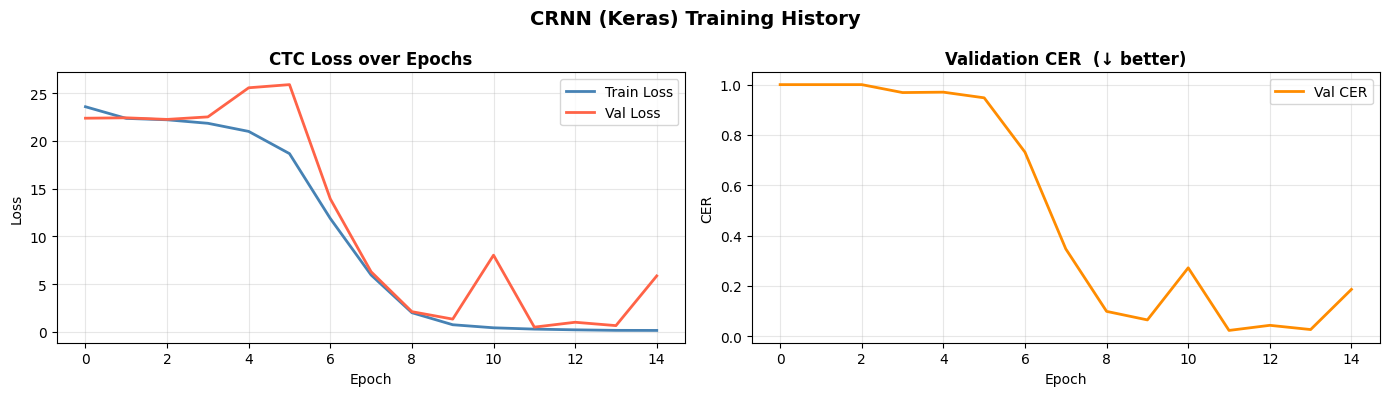

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history["loss"],     label="Train Loss", color="steelblue", lw=2)
ax1.plot(history.history["val_loss"], label="Val Loss",   color="tomato",    lw=2)
ax1.set_title("CTC Loss over Epochs", fontweight="bold", fontsize=12)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(cer_callback.cer_history, label="Val CER", color="darkorange", lw=2)
ax2.set_title("Validation CER  (↓ better)", fontweight="bold", fontsize=12)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("CER")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("CRNN (Keras) Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()


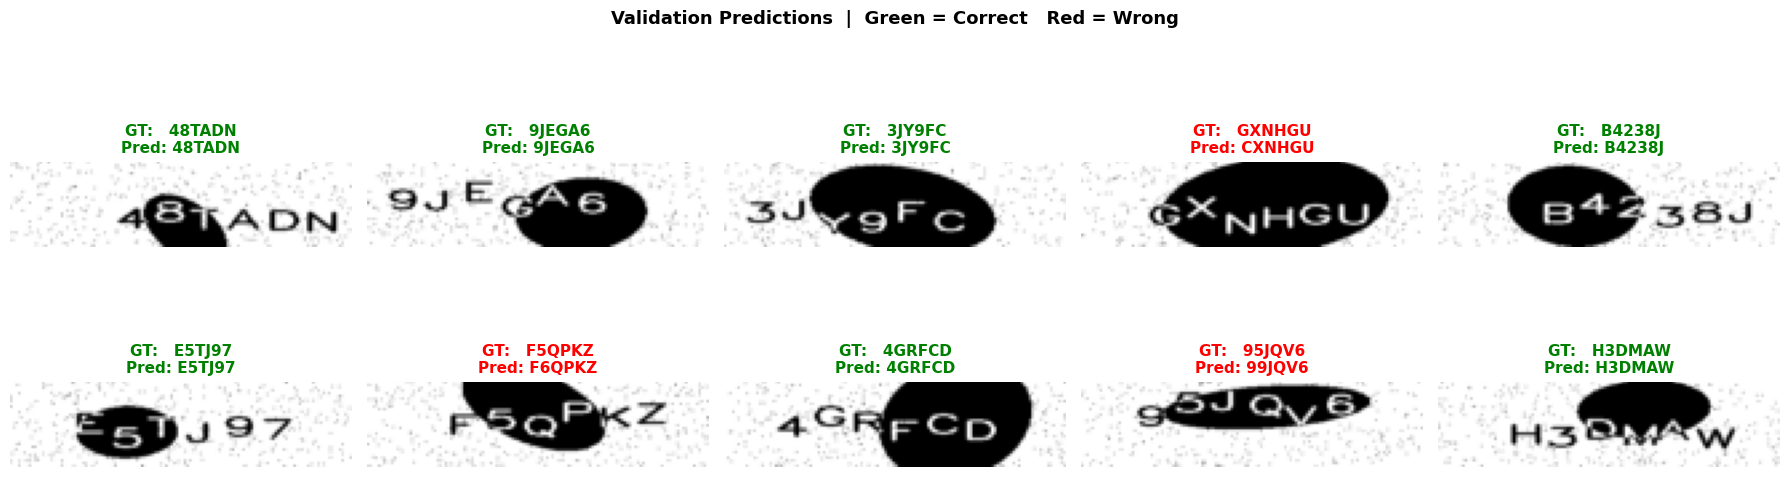

In [22]:
training_model.load_weights(CKPT_PATH)

inputs, _ = val_gen[0]
images     = inputs["image"]
labels     = inputs["label"]
label_lens = inputs["label_length"].flatten()

y_pred = prediction_model.predict(images, verbose=0)
preds  = greedy_decode(y_pred, idx2char, BLANK)
gts    = ["".join(idx2char.get(int(c), "") for c in labels[i, :label_lens[i]])
          for i in range(len(preds))]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for i, ax in enumerate(axes.flatten()):
    img_np = images[i].squeeze()           # (H, W)
    ax.imshow(img_np, cmap="gray")
    color = "green" if preds[i] == gts[i] else "red"
    ax.set_title(f"GT:   {gts[i]}\nPred: {preds[i]}",
                 color=color, fontsize=11, fontweight="bold")
    ax.axis("off")

plt.suptitle("Validation Predictions  |  Green = Correct   Red = Wrong",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "val_predictions.png"), dpi=120, bbox_inches="tight")
plt.show()


In [23]:
import numpy as np

def evaluate_full(prediction_model, generator, idx2char, blank_idx):
    all_cer    = []
    exact_match = 0
    total       = 0

    for i in range(len(generator)):
        inputs, _  = generator[i]
        images     = inputs["image"]
        labels     = inputs["label"]
        label_lens = inputs["label_length"].flatten()

        y_pred = prediction_model.predict(images, verbose=0)
        preds  = greedy_decode(y_pred, idx2char, blank_idx)

        for j, (pred, llen) in enumerate(zip(preds, label_lens)):
            gt = "".join(idx2char.get(int(c), "") for c in labels[j, :llen])
            all_cer.append(cer(pred, gt))
            if pred == gt:
                exact_match += 1
            total += 1

    mean_cer  = np.mean(all_cer)
    accuracy  = exact_match / total * 100

    print("=" * 40)
    print(f"  Total samples evaluated : {total}")
    print(f"  Exact Match Accuracy    : {accuracy:.2f}%")
    print(f"  Mean CER                : {mean_cer:.4f}")
    print(f"  Mean CER %              : {mean_cer * 100:.2f}%")
    print("=" * 40)

    return mean_cer, accuracy

mean_cer, accuracy = evaluate_full(prediction_model, val_gen, idx2char, BLANK)

  Total samples evaluated : 2000
  Exact Match Accuracy    : 87.50%
  Mean CER                : 0.0225
  Mean CER %              : 2.25%


In [24]:
inputs, _ = val_gen[0]
images     = inputs["image"]
labels     = inputs["label"]
label_lens = inputs["label_length"].flatten()

y_pred = prediction_model.predict(images, verbose=0)
preds  = greedy_decode(y_pred, idx2char, BLANK)

print(f"{'Ground Truth':<15} {'Predicted':<15} {'Correct?'}")
print("-" * 40)
for j in range(20):
    gt      = "".join(idx2char.get(int(c), "") for c in labels[j, :label_lens[j]])
    correct = "✓" if preds[j] == gt else "✗"
    print(f"{gt:<15} {preds[j]:<15} {correct}")

Ground Truth    Predicted       Correct?
----------------------------------------
48TADN          48TADN          ✓
9JEGA6          9JEGA6          ✓
3JY9FC          3JY9FC          ✓
GXNHGU          CXNHGU          ✗
B4238J          B4238J          ✓
E5TJ97          E5TJ97          ✓
F5QPKZ          F6QPKZ          ✗
4GRFCD          4GRFCD          ✓
95JQV6          99JQV6          ✗
H3DMAW          H3DMAW          ✓
U48BHM          U48BHM          ✓
BESG7W          BESC7W          ✗
MT2W8S          MT2W8S          ✓
DKMPAM          DKMPAM          ✓
J6U76F          J6U76F          ✓
MT3TS8          MT3TS8          ✓
M9YU2F          M9YU2F          ✓
WR5YS8          WR5YS8          ✓
ZBR6RH          ZBR6RH          ✓
YGZXZX          YGZXZX          ✓


In [25]:
from collections import defaultdict

char_correct = defaultdict(int)
char_total   = defaultdict(int)

for i in range(len(val_gen)):
    inputs, _  = val_gen[i]
    images     = inputs["image"]
    labels     = inputs["label"]
    label_lens = inputs["label_length"].flatten()

    y_pred = prediction_model.predict(images, verbose=0)
    preds  = greedy_decode(y_pred, idx2char, BLANK)

    for j, (pred, llen) in enumerate(zip(preds, label_lens)):
        gt = "".join(idx2char.get(int(c), "") for c in labels[j, :llen])
        for ch in gt:
            char_total[ch] += 1
            if ch in pred:
                char_correct[ch] += 1

print(f"\n{'Char':<6} {'Correct':<10} {'Total':<10} {'Acc %'}")
print("-" * 35)
for ch in sorted(char_total.keys()):
    acc = char_correct[ch] / char_total[ch] * 100
    print(f"{ch:<6} {char_correct[ch]:<10} {char_total[ch]:<10} {acc:.1f}%")


Char   Correct    Total      Acc %
-----------------------------------
2      356        356        100.0%
3      326        326        100.0%
4      385        387        99.5%
5      382        394        97.0%
6      385        414        93.0%
7      398        398        100.0%
8      392        405        96.8%
9      392        394        99.5%
A      392        393        99.7%
B      353        359        98.3%
C      384        385        99.7%
D      357        362        98.6%
E      400        409        97.8%
F      400        406        98.5%
G      307        383        80.2%
H      399        400        99.8%
J      394        394        100.0%
K      391        391        100.0%
M      404        405        99.8%
N      398        398        100.0%
P      386        390        99.0%
Q      391        400        97.8%
R      387        389        99.5%
S      380        384        99.0%
T      373        380        98.2%
U      373        373        100.0%
V      358 

In [26]:
pip_install("tqdm")
from tqdm import tqdm

test_files = sorted(os.listdir(TEST_IMG_DIR))
all_fnames, all_preds = [], []

def load_test_image(fname):
    img = Image.open(os.path.join(TEST_IMG_DIR, fname)).convert("L")
    img = img.resize((IMG_W, IMG_H), Image.BILINEAR)
    img = np.array(img, dtype=np.float32) / 255.0
    return img[..., np.newaxis]   # (H, W, 1)

# Predict in batches
for i in tqdm(range(0, len(test_files), BATCH_SIZE), desc="Predicting"):
    batch_files = test_files[i:i + BATCH_SIZE]
    batch_imgs  = np.stack([load_test_image(f) for f in batch_files])

    y_pred = prediction_model.predict(batch_imgs, verbose=0)
    preds  = greedy_decode(y_pred, idx2char, BLANK)

    all_fnames.extend(batch_files)
    all_preds.extend(preds)

sub = (pd.DataFrame({"image": all_fnames, "prediction": all_preds})
         .sort_values("image")
         .reset_index(drop=True))

SUBMISSION_FILE = os.path.join(BASE_DIR, "SakshiKanhere_23112088.csv")
sub.to_csv(SUBMISSION_FILE, index=False)

print(f"\nSaved {len(sub)} predictions → {SUBMISSION_FILE}")
print("\nSample predictions:")
print(sub.head(10).to_string(index=False))

Predicting: 100%|██████████| 40/40 [00:11<00:00,  3.38it/s]


Saved 5000 predictions → /content/cig_ps/JayJain_23112045.csv

Sample predictions:
        image prediction
   test-0.png     QVTQ8A
   test-1.png     7PSW9D
  test-10.png     7DUP98
 test-100.png     75Z4WT
test-1000.png     QAKZ7V
test-1001.png     R6MERY
test-1002.png     CHXX67
test-1003.png     9NV2WP
test-1004.png     F56TDZ
test-1005.png     FFTFRX


In [27]:
import pandas as pd
from google.colab import files


sub = pd.read_csv("/content/cig_ps/JayJain_23112045.csv")

print(f"Total predictions : {len(sub)}")
print(f"Columns           : {list(sub.columns)}")
print(f"\nFirst 10 rows:")
print(sub.head(10).to_string(index=False))


empty = sub[sub["prediction"].isna() | (sub["prediction"] == "")]
print(f"\nEmpty predictions : {len(empty)}")


import shutil
src = "/content/cig_ps/JayJain_23112045.csv"
dst = "/content/submission_JayJain_23112045.csv"
shutil.copy(src, dst)

files.download(dst)
print("\nDownloaded ✓")

Total predictions : 5000
Columns           : ['image', 'prediction']

First 10 rows:
        image prediction
   test-0.png     QVTQ8A
   test-1.png     7PSW9D
  test-10.png     7DUP98
 test-100.png     75Z4WT
test-1000.png     QAKZ7V
test-1001.png     R6MERY
test-1002.png     CHXX67
test-1003.png     9NV2WP
test-1004.png     F56TDZ
test-1005.png     FFTFRX

Empty predictions : 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded ✓
